In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d salader/dogs-vs-cats

Dataset URL: https://www.kaggle.com/datasets/salader/dogs-vs-cats
License(s): unknown
100% 1.06G/1.06G [00:47<00:00, 24.5MB/s]
100% 1.06G/1.06G [00:47<00:00, 23.9MB/s]


In [ ]:
import zipfile
zip = zipfile.ZipFile('/content/dogs-vs-cats.zip')
zip.extractall('/content')
zip.close()

In [ ]:
import tensorflow
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

In [ ]:
train_data = keras.utils.image_dataset_from_directory(
    directory= '/content/train',
    labels = 'inferred',
    label_mode= 'int',
    batch_size = 50,
    image_size = (300,300),
)

Found 20000 files belonging to 2 classes.


In [ ]:
test_data = keras.utils.image_dataset_from_directory(
    directory= '/content/test',
    labels = 'inferred',
    label_mode= 'int',
    batch_size = 50,
    image_size = (300,300),
)

Found 5000 files belonging to 2 classes.


In [ ]:
## Normalize The Data
test_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
def normalize(img, label):
  image = tensorflow.cast(img/255, 'float')
  return image, label

In [ ]:
train_data = train_data.map(normalize)

In [ ]:
test_data = test_data.map(normalize)

In [ ]:
## Building our model
model = Sequential()

model.add(Conv2D(32, kernel_size = (3,3), strides = (2,2), padding = 'same', activation = 'relu', input_shape = (300,300,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2),padding = 'same'))

model.add(Conv2D(64, kernel_size = (3,3), strides = (2,2), padding = 'same', activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2),padding = 'same'))

model.add(Conv2D(64, kernel_size = (3,3), strides = (2,2), padding = 'same', activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2),padding = 'same'))

model.add(Flatten())

model.add(Dense(128, activation = 'relu'))
model.add(Dropout(0.2))

model.add(Dense(64, activation = 'relu'))
model.add(Dropout(0.2))

model.add(Dense(1, activation = 'sigmoid'))

In [ ]:
##Compile model along with specified loss and optimizer
model.compile(optimizer = 'Adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [ ]:
history = model.fit(train_data, epochs = 20, validation_data = test_data)

Epoch 1/20
400/400 [==============================] - 75s 166ms/step - loss: 0.5997 - accuracy: 0.6781 - val_loss: 0.8535 - val_accuracy: 0.5356
Epoch 2/20
400/400 [==============================] - 57s 142ms/step - loss: 0.4893 - accuracy: 0.7668 - val_loss: 0.4910 - val_accuracy: 0.7740
Epoch 3/20
400/400 [==============================] - 55s 137ms/step - loss: 0.4219 - accuracy: 0.8066 - val_loss: 0.4938 - val_accuracy: 0.7712
Epoch 4/20
400/400 [==============================] - 68s 170ms/step - loss: 0.3650 - accuracy: 0.8364 - val_loss: 0.3895 - val_accuracy: 0.8248
Epoch 5/20
400/400 [==============================] - 56s 139ms/step - loss: 0.3208 - accuracy: 0.8575 - val_loss: 0.4046 - val_accuracy: 0.8242
Epoch 6/20
400/400 [==============================] - 67s 165ms/step - loss: 0.2808 - accuracy: 0.8791 - val_loss: 0.4605 - val_accuracy: 0.7878
Epoch 7/20
400/400 [==============================] - 50s 124ms/step - loss: 0.2356 - accuracy: 0.9026 - val_loss: 0.4272 - val_ac

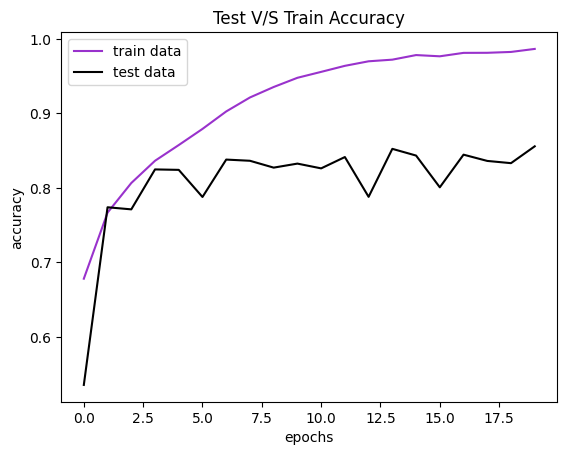

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color = 'darkorchid', label = 'train data')
plt.plot(history.history['val_accuracy'], color = 'black', label = 'test data')
plt.title('Test V/S Train Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()

# Time to Test

In [ ]:
import cv2

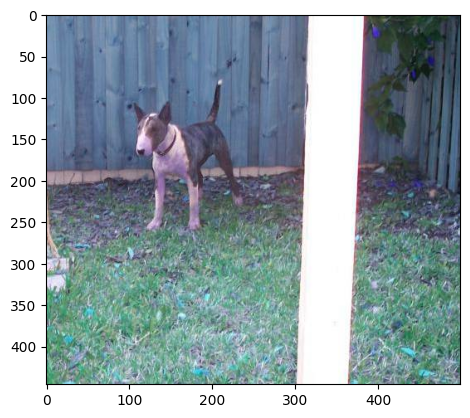

In [ ]:
img1 = cv2.imread('/content/test/dogs/dog.10073.jpg')
plt.imshow(img1)

In [ ]:
## resize the image

testImg1 = cv2.resize(img1, (300, 300))
testImg1_correctFormat = testImg1.reshape((1,300,300,3))

In [ ]:
model.predict(testImg1_correctFormat)[0]

1/1 [==============================] - 0s 29ms/step


array([1.], dtype=float32)